# Table of contents

* **Introduction**
* **Objective**
* **Perceptron Foundations**
* **Data Dictionary**
* **Pipeline Overview**
* **Approach**
* **Setup Environments**
* **Exploratory Data Analysis (EDA)**
* **Features Engineering**
* **Model Training and Experiments**
    * Model Architecture and Model Training
* **Model Evaluation**
* **Conclusion**
* **References**

# Introduction

The Perceptron, an elementary linear binary classification algorithm, forms the historical foundation of modern neural networks. Developed in 1958, its function is to learn a set of weights that define a linear decision boundary capable of separating two classes in a feature space. This project applies the Scikit-Learn implementation of the Perceptron to a complex, high-dimensional dataset derived from dynamic API call sequences, classifying programs as malicious (malware) or benign. The goal is to explore how this simple linear model performs on real-world cybersecurity data, where the challenges of high dimensionality and severe class imbalance are prominent.

# Objective

The primary objectives center on demonstrating a complete and robust machine learning workflow while critically examining the Perceptron's intrinsic limitations. The project aims to:

- Execute the classic Perceptron algorithm using `sklearn.linear_model.Perceptron`.
- Illustrate a comprehensive pipeline, including standardized data handling, dimensionality reduction via Principal Component Analysis (PCA), and mitigation of class imbalance using SMOTE.
- Visualize the model's behavior by plotting its learned linear decision boundary in a 2D PCA-transformed space, offering an intuitive understanding of its mechanism.
- Highlight the fundamental challenge linear models face when applied to data that is not linearly separable and suffers from severe class imbalance.

# Perceptron Foundations

The Perceptron is the simplest form of an artificial neural network, representing a linear binary classifier. Developed by Frank Rosenblatt in 1957, it models a single neuron's ability to make a decision by combining input features.

**Core Architecture and Function**

The Perceptron operates by taking a set of inputs, processing them through a weighted sum, and then passing the result through an activation function to produce an output.

1. Input and Weights: An input vector $x = [x_1, x_2, \ldots, x_n]$ is received, corresponding to the feature values of a sample. Each input is associated with a synaptic weight vector $w = [w_1, w_2, \ldots, w_n]$, which determines the importance of the corresponding input feature. A bias term, $b$, is also included, which can be thought of as an extra input with a fixed value of 1.

2. Net Input Function: The first step is the computation of the net input, $z$. This calculation is the sum of the weighted inputs plus the bias term, representing a linear combination of the input features. This is mathematically expressed as the dot product of the input vector and the weight vector, plus the bias:

$$z = \sum_{i=1}^{n} (x_i w_i) + b = w^T x + b$$

3. Activation Function: The net input $z$ is then fed into an activation function, $f(z)$, to determine the output (the prediction). The classical Perceptron uses the Heaviside step function (or sign function) as its activation function. This function returns 1 if the net input is positive or zero, and 0 (or -1, depending on the convention) if the net input is negative. The output prediction $\hat{y}$ is:

$$\hat{y} = f(z) = \begin{cases} 1 & \text{if } w^T x + b \ge 0 \\ 0 & \text{if } w^T x + b < 0 \end{cases}$$

**The Learning Mechanism: Perceptron Learning Rule**

The learning process is an iterative, supervised approach designed to minimize classification errors. The Perceptron learning rule is a modification rule that updates the weights only when a misclassification occurs.

- Goal: To find a set of weights $w$ and a bias $b$ that correctly separates the two classes.
- Initialization: Weights and bias are typically initialized to small random values or zero.
- Update Rule: For each training sample $(x^{(j)}, y^{(j)})$ where a misclassification occurs (i.e., $y^{(j)} \ne \hat{y}^{(j)}$):
    - The weight vector is updated according to the following formula:$$w^{(t+1)} = w^{(t)} + \Delta w$$where the change in weights $\Delta w$ is:$$\Delta w = \eta (y^{(j)} - \hat{y}^{(j)}) x^{(j)}$$
      $\eta$ (eta) is the learning rate, a hyperparameter controlling the magnitude of the weight adjustments. A smaller $\eta$ leads to slower but potentially more stable convergence.
      $y^{(j)}$ is the true class label (target).
      $\hat{y}^{(j)}$ is the predicted class label (output).
      $(y^{(j)} - \hat{y}^{(j)})$ is the error, which can only be $-1$, $0$, or $1$.

**Mechanism of Update:**

- If the prediction is too high ($\hat{y}=1$ and $y=0$): $w$ is moved away from $x^{(j)}$.
- If the prediction is too low ($\hat{y}=0$ and $y=1$): $w$ is moved toward $x^{(j)}$.
- If the prediction is correct, the weights remain unchanged ($\Delta w = 0$).

The bias is updated similarly:


$$\Delta b = \eta (y^{(j)} - \hat{y}^{(j)})$$

This iterative process continues for a fixed number of epochs or until a stopping criterion is met.

**Linear Separability Constraint**

The most significant theoretical constraint of the Perceptron is its requirement for linear separability.
- Concept: The Perceptron can only perfectly classify data if the two classes can be separated by a single straight line (in 2D), a plane (in 3D), or a hyperplane (in higher dimensions). The vector $w$ defines the normal to this decision boundary hyperplane.
- Perceptron Convergence Theorem: This theorem states that if and only if the training data is linearly separable, the Perceptron algorithm is guaranteed to find a solution (a separating hyperplane) in a finite number of steps.
- Limitation: The inability of a single-layer Perceptron to solve non-linearly separable problems (famously demonstrated by the XOR problem) led to a temporary decline in neural network research until the development of multi-layer networks, which employ hidden layers and non-linear activation functions to overcome this limitation.

**Practical Considerations**

- Feature Scaling: Prior to training, it is crucial to standardize or normalize the input features. Features on different scales can cause the Perceptron's weight updates to be disproportionate, leading to slower convergence or oscillation. Techniques like $Z$-score standardization or min-max scaling ensure all features contribute equally to the distance calculation.
- Overfitting: The Perceptron does not inherently possess regularization mechanisms. While it converges if the data is linearly separable, for real-world, non-separable data, the algorithm may never fully converge, resulting in weights that oscillate. Training for too many epochs on separable data can also lead to overfitting if the data contains outliers or noise.

# Data Dictionary

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-za14">Column Name</th>
    <th class="tg-7zrl">Description</th>
    <th class="tg-7zrl">Data Type</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">hash</td>
    <td class="tg-7zrl">Unique identifier for each record</td>
    <td class="tg-7zrl">Alphanumeric</td>
  </tr>
  <tr>
    <td class="tg-7zrl">t_0 - t_99</td>
    <td class="tg-7zrl">Time series measurement at index 0-99</td>
    <td class="tg-7zrl">Numerical (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">malware</td>
    <td class="tg-7zrl">Goodware (0) and Malware (1)</td>
    <td class="tg-7zrl">Categorical (Class)</td>
  </tr>
</tbody>
</table>

**[Dataset Link](https://www.kaggle.com/datasets/mirichoi0218/insurance)**

# Pipeline Overview

The project follows a rigorous, multi-step pipeline designed for reproducible classification results and insightful analysis:

- Data Ingestion and Initial Cleaning: Loading the 100-dimensional API call data and removing non-feature columns (identifiers) and missing entries.
- Preprocessing and Scaling: Standardization of features to ensure equal contribution during training.
- Dimensionality Reduction: Application of PCA to project the 100 features down to 2 dimensions.
- Class Imbalance Mitigation: Balancing the training set using SMOTE to address the disproportionate class distribution ($\approx 97.5%$ malware, $\approx 2.5%$ benign).
- Model Training: Implementing the Perceptron and optimizing its hyperparameters via cross-validation.
- Comprehensive Evaluation: Measuring performance using standard metrics and visual aids, focusing on the model's behavior on the original, unseen test data.

# Approach

**Preprocessing Pipeline Approach**

A strict, leakage-free preprocessing strategy is essential for valid evaluation:
- Initial Data Cleaning: The project starts by discarding the hash identifier column and managing any rows with missing feature values to ensure data integrity.
- Feature Scaling (Standardization): The 100 API call features are standardized using StandardScaler. This process transforms the data such that it has zero mean and unit variance. Critically, the scaler is fitted exclusively on the training data and then applied to both the training and test sets. This prevents data leakage, where information from the test set could inadvertently influence the scaling parameters.
- Dimensionality Reduction (PCA): Principal Component Analysis is applied to reduce the dimensionality from 100 to 2. PCA finds the orthogonal directions (principal components) that maximize variance in the data. This reduction is performed primarily to enable the visualization of the linear decision boundary and to potentially reduce noise.
- Class Imbalance Handling (SMOTE): The severe class imbalance is addressed using the Synthetic Minority Over-sampling Technique (SMOTE). SMOTE generates synthetic examples of the minority class (benign) by interpolating between existing minority instances. This technique is applied only to the PCA-reduced training data, never to the test set, ensuring the model is trained on a balanced distribution (50-50) while maintaining an unbiased evaluation on the original imbalanced test set.

**Model Training Approach**

The Perceptron algorithm, defined by the update rule $\mathbf{w} \leftarrow \mathbf{w} + \eta(y - \hat{y})\mathbf{x}$ for misclassified samples, serves as the core model. Here, $\mathbf{w}$ is the weight vector, $\eta$ is the learning rate, $y$ is the true label, $\hat{y}$ is the predicted label, and $\mathbf{x}$ is the feature vector.
- Implementation: Scikit-Learn's Perceptron is instantiated with specific hyperparameters (e.g., `alpha` for regularization, `eta0` for the learning rate).
- Hyperparameter Optimization: `GridSearchCV` is employed with 5-fold stratified cross-validation on the balanced training data. This searches exhaustively across a predefined grid of parameters (including `alpha, eta0`, and convergence settings like `max_iter` and tol) to identify the combination that yields the highest cross-validated accuracy.
- Final Training: The optimized Perceptron model is then trained on the full, SMOTE-balanced, PCA-reduced 2D training dataset.

**Model Evaluation Approach**

Evaluation focuses on assessing the model's generalization ability on the original, unbalanced test set, combining quantitative metrics with qualitative visualization:
- Quantitative Metrics: Performance is measured using a comprehensive suite of metrics that address the classification task:
    - Accuracy, Precision, Recall, and F1-score: These are often macro-averaged to ensure equal weighting between the majority and minority classes.
    - Confusion Matrix: Provides a detailed breakdown of correct and incorrect classifications (True Positives, False Positives, etc.).
    - AUC-ROC Curve: Measures the model's ability to distinguish between classes across all possible classification thresholds.
    - Precision-Recall Curve: Particularly important in imbalanced classification to assess performance on the minority class.
- Visualization-Focused Insights: The project leverages the 2D PCA space to:
    - Plot the Decision Boundary: A straight line representing the Perceptron's learned hyperplane. This visually illustrates that the model is fundamentally limited to linear separations.
    - Demonstrate the Linear Limitation: By observing the distribution of the actual data points relative to this straight line, the visualization reveals how the Perceptron struggles when the classes are intertwined or require a non-linear boundary for optimal separation.

# Setup Environments

**Packages Installation**

In [29]:
%%capture
!pip install imblearn
!pip install imbalanced-learn==0.10.1
!pip install --upgrade imbalanced-learn

**Import Libraries**

In [30]:
import numpy as np
import pylab as pl
import pandas as pd
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.model_selection import cross_val_score, GridSearchCV
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import Perceptron
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification
from sklearn.linear_model import Perceptron # Import Perceptron
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.metrics import (
    precision_recall_curve, auc, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, roc_curve
)

**Data Loading**

The project commences with loading the dataset, which contains high-dimensional API call sequences used for malware classification. The raw data consists of 100 sequential feature columns ($t_0$ through $t_{99}$) and two metadata columns: a unique hash identifier and the binary target variable, malware.

The initial preparation phase involves two critical steps:

- Identifier Removal: The non-predictive hash column is removed. This column holds no functional information for the classifier and its inclusion would violate the principles of feature relevance.
- Missing Value Management: Any rows containing missing values (NaN) are dropped. Given the nature of sequential data, a sample with incomplete information is often unusable, justifying the complete removal of affected entries to maintain dataset integrity.

In [3]:
# reading data
df = pd.read_csv('/kaggle/input/malware-analysis-datasets-api-call-sequences/dynamic_api_call_sequence_per_malware_100_0_306.csv')
df.head()

,hash,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,...,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99,malware
0,071e8c3f8922e186e57548cd4c703a5d,112,274,158,215,274,158,215,298,76,...,71,297,135,171,215,35,208,56,71,1
1,33f8e6d08a6aae939f25a8e0d63dd523,82,208,187,208,172,117,172,117,172,...,81,240,117,71,297,135,171,215,35,1
2,b68abd064e975e1c6d5f25e748663076,16,110,240,117,240,117,240,117,240,...,65,112,123,65,112,123,65,113,112,1
3,72049be7bd30ea61297ea624ae198067,82,208,187,208,172,117,172,117,172,...,208,302,208,302,187,208,302,228,302,1
4,c9b3700a77facf29172f32df6bc77f48,82,240,117,240,117,240,117,240,117,...,209,260,40,209,260,141,260,141,260,1


**Initial Cleaning**

In [4]:
df = df.drop(columns=['hash'],axis=1)
df = df.dropna(how='any')
df

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99,malware
0,112,274,158,215,274,158,215,298,76,208,...,71,297,135,171,215,35,208,56,71,1
1,82,208,187,208,172,117,172,117,172,117,...,81,240,117,71,297,135,171,215,35,1
2,16,110,240,117,240,117,240,117,240,117,...,65,112,123,65,112,123,65,113,112,1
3,82,208,187,208,172,117,172,117,172,117,...,208,302,208,302,187,208,302,228,302,1
4,82,240,117,240,117,240,117,240,117,172,...,209,260,40,209,260,141,260,141,260,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43871,82,240,117,240,117,240,117,240,117,172,...,141,260,141,260,141,260,141,260,141,1
43872,82,240,117,240,117,240,117,240,117,172,...,159,224,82,159,224,82,159,224,82,1
43873,82,240,117,240,117,240,117,240,117,172,...,260,141,260,141,260,141,260,141,260,1
43874,82,240,117,240,117,240,117,240,117,172,...,141,260,141,260,141,260,141,260,141,1


**Train and Test Split**

To enable fair training and unbiased evaluation, the cleaned dataset is partitioned into training and testing sets using the train-test split methodology. A standard $80$ percent / $20$ percent split ratio is employed. The data is partitioned before any further preprocessing steps (like scaling or oversampling) occur. This strict separation prevents data leakage, ensuring that the model's training process remains completely unaware of the data points in the unseen test set, which is crucial for estimating true generalization performance.

In [ ]:
train, test = train_test_split(df, test_size=0.2, random_state=42) 

print("train shape:", train.shape)
print("test shape:", test.shape)

train shape: (35100, 101)
test shape: (8776, 101)


# Exploratory Data Analysis (EDA)

**Basic Statistics**

Exploratory analysis focuses on understanding the structure and distribution of the prepared data partitions:

- Dimensionality: The resulting training set maintains 100 feature columns plus the target, demonstrating the high dimensionality of the API sequence data.
- Feature Distribution: Descriptive statistics, such as mean, standard deviation, and quartiles, are examined across the 100 features. The wide range of values and large standard deviations across features (API call IDs) suggest that feature scaling will be a mandatory requirement to ensure the Perceptron's weight updates are not disproportionately influenced by features with larger initial magnitudes.
- Data Types: The data types are confirmed to be integers (int64), consistent with the nature of encoded API call identifiers.
- Missing Value Check: A final check confirms that no missing values exist in either the training or testing sets, validating the effectiveness of the initial cleaning step.

In [6]:
train.head()

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99,malware
35602,112,274,158,215,274,158,215,298,76,208,...,71,297,135,171,215,35,208,56,71,1
13858,112,274,158,215,274,158,215,298,76,208,...,172,117,172,117,172,117,172,117,172,1
39770,112,274,158,215,274,158,215,298,76,208,...,71,297,135,171,215,35,208,56,71,1
1024,208,286,76,110,240,117,208,187,208,198,...,286,240,286,117,208,286,240,286,117,1
31154,82,208,187,208,172,117,172,208,16,208,...,117,172,117,208,172,117,100,215,35,1


In [7]:
train.describe()

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99,malware
count,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,...,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000
mean,142.787123,211.254872,148.203333,188.834245,187.417949,174.108063,170.378148,199.045271,142.807322,167.325413,...,154.204786,173.156809,159.560484,164.906980,173.463419,152.373533,158.394758,160.395926,155.748262,0.975698
std,75.600839,60.294950,47.698712,68.358486,71.255625,65.739453,55.525942,65.516243,66.800136,53.441632,...,78.291792,82.742852,74.071577,70.322547,70.531624,79.906061,78.029384,75.022546,78.949398,0.153987
min,2.000000,2.000000,2.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,82.000000,172.000000,117.000000,117.000000,117.000000,117.000000,117.000000,159.000000,117.000000,117.000000,...,81.000000,117.000000,114.000000,117.000000,117.000000,89.000000,100.000000,108.000000,73.000000,1.000000
50%,82.000000,240.000000,158.000000,215.000000,172.000000,158.000000,172.000000,215.000000,117.000000,172.000000,...,141.000000,172.000000,141.000000,171.000000,172.000000,141.000000,171.000000,156.000000,141.000000,1.000000
75%,215.000000,240.000000,172.000000,240.000000,274.000000,240.000000,215.000000,240.000000,208.000000,208.000000,...,240.000000,260.000000,240.000000,215.000000,240.000000,215.000000,224.000000,225.000000,225.000000,1.000000
max,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,...,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,1.000000


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35100 entries, 35602 to 15795
Columns: 101 entries, t_0 to malware
dtypes: int64(101)
memory usage: 27.3 MB


In [9]:
train.isnull().sum()

t_0        0
t_1        0
t_2        0
t_3        0
t_4        0
          ..
t_96       0
t_97       0
t_98       0
t_99       0
malware    0
Length: 101, dtype: int64

In [10]:
test.isnull().sum()

t_0        0
t_1        0
t_2        0
t_3        0
t_4        0
          ..
t_96       0
t_97       0
t_98       0
t_99       0
malware    0
Length: 101, dtype: int64

**Target Labels Distribution**

In [11]:
train['malware'].value_counts(normalize=True)*100

malware
1    97.569801
0     2.430199
Name: proportion, dtype: float64

A crucial discovery from the exploratory phase is the severe imbalance in the target variable, malware.

- Imbalance Ratio: The analysis of the malware column reveals that the majority class (malware=1) dominates the dataset, comprising approximately $97.6$ percent of the samples, while the minority class (benign=0) accounts for only about $2.4$ percent.
- Implication for Modeling: This extreme class imbalance poses a major challenge for linear classifiers like the Perceptron.  A model trained on such skewed data tends to exhibit a high overall accuracy by simply classifying all samples as the majority class, masking its inability to correctly identify the minority class (benign programs). This observation dictates the necessity of employing a mitigation technique, such as SMOTE, during the subsequent preprocessing and training phases to ensure the model learns meaningful decision boundaries for both classes.

**Visualization of Class Distribution**

The class distribution is visualized using a bar plot to highlight the disparity between the number of malware and benign samples. This visual confirmation underscores the numerical findings and reinforces the immediate need for imbalance handling to avoid a trivially biased classifier.

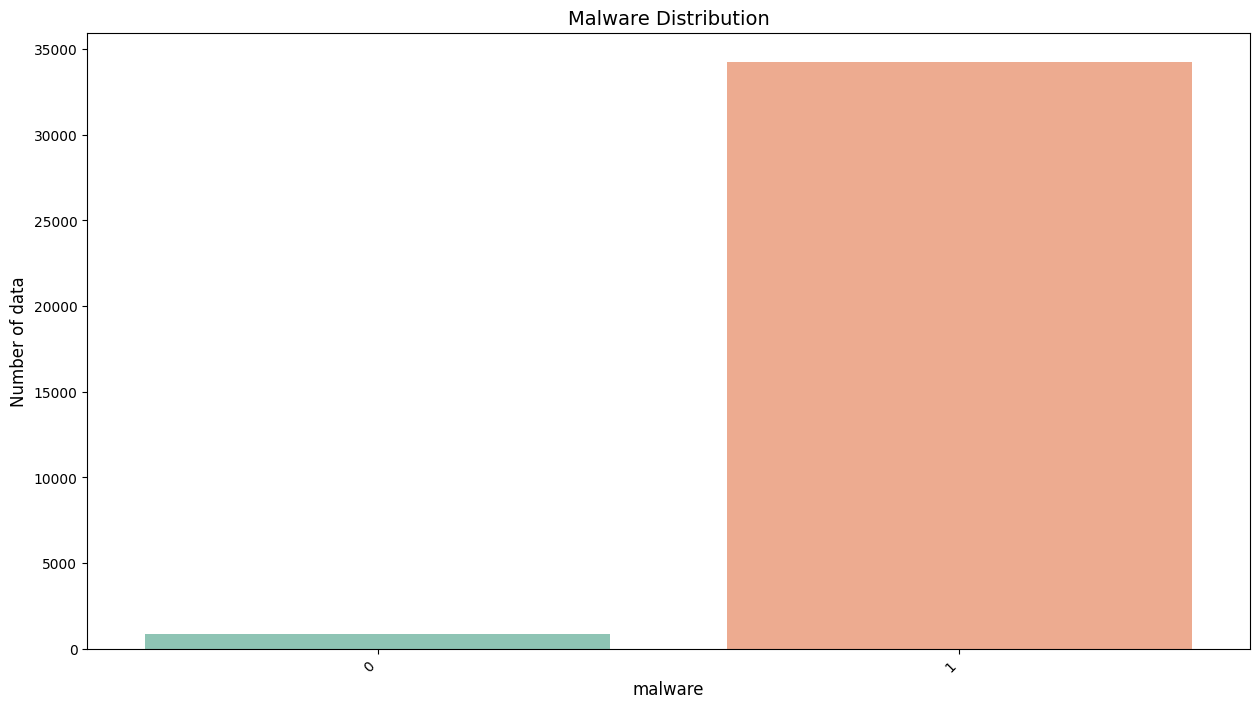

In [ ]:
cnt_pro = train['malware'].value_counts()

plt.figure(figsize=(15,8))
ax = sns.barplot(x=cnt_pro.index, y=cnt_pro.values, alpha=0.8, palette="Set2")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.ylabel('Number of data', fontsize=12)
plt.xlabel('malware', fontsize=12)
plt.title('Malware Distribution', fontsize=14)
plt.show()

# Features Engineering

**Features and Target Labels Split**

The initial stage of feature engineering involves correctly partitioning the data into feature matrices ($X$) and target vectors ($y$) for both the training and testing sets. This step ensures that the independent variables (the 100 API call features, $t_0$ to $t_{99}$) are isolated from the dependent variable (malware).

- Training Set: X_train receives the 100 features from the original train data, and `y_train` receives the corresponding binary malware labels.
- Test Set: `X_test` and `y_test` are created similarly from the test data.

This explicit separation is critical as it defines the inputs and outputs used by the subsequent scaling and model training steps.

In [ ]:
y_train = train['malware'] 
x_test = test.drop('malware', axis=1) 
y_test = test['malware'] 
x_train = train.drop('malware', axis=1) 

print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (35100, 100)
y_train shape: (35100,)
X_test shape: (8776, 100)
y_test shape: (8776,)


**Data Normalization (Standardization)**

The core concept applied here is standardization using the StandardScaler. This preprocessing technique is mandatory for distance-based algorithms like Perceptron, which are sensitive to the magnitude of the input features.

- Standardization: Standardization transforms the data such that each feature column has a mean of 0 and a standard deviation of 1. The transformation formula for a feature $x$ is:$$x_{\text{std}} = \frac{x - \mu}{\sigma}$$where $\mu$ is the mean and $\sigma$ is the standard deviation.
- Leakage Prevention: The StandardScaler must be fitted exclusively on the training data (`X_train`). The resulting mean and standard deviation learned from `X_train` are then used to transform `X_train` itself (`X_train_std`) and, critically, `X_test` (`X_test_std`). This strict procedure prevents data leakage from the test set into the model's training process, ensuring an unbiased evaluation.

The resulting standardized training features confirm that the mean is approximately zero and the standard deviation is 1 for all 100 features.

In [ ]:
scaler = StandardScaler()

x_train_std = scaler.fit_transform(x_train)
x_test_std = scaler.transform(x_test)

In [ ]:
x_train_std = pd.DataFrame(x_train_std, columns=x_train.columns)
x_test_std = pd.DataFrame(x_test_std, columns=x_test.columns)
x_train_std.describe()

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_90,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99
count,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,...,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04
mean,-1.530400e-16,-1.220676e-16,-2.702492e-16,-1.805710e-16,-1.781418e-17,-6.498126e-17,7.530538e-17,8.502221e-18,-1.064802e-16,2.206529e-17,...,3.623566e-17,1.651860e-16,2.753100e-17,-1.615422e-16,1.595179e-16,2.200456e-16,1.388696e-16,1.046583e-16,2.672127e-17,-2.186285e-17
std,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,...,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00
min,-1.862269e+00,-3.470570e+00,-3.065186e+00,-2.733193e+00,-2.630257e+00,-2.648494e+00,-3.068486e+00,-3.007622e+00,-2.137860e+00,-3.093614e+00,...,-1.988217e+00,-1.969644e+00,-2.092740e+00,-2.154170e+00,-2.345042e+00,-2.459406e+00,-1.906935e+00,-2.029966e+00,-2.138000e+00,-1.972789e+00
25%,-8.040650e-01,-6.510567e-01,-6.541849e-01,-1.050861e+00,-9.882581e-01,-8.687154e-01,-9.613328e-01,-6.112353e-01,-3.863419e-01,-9.417027e-01,...,-5.210352e-01,-9.350384e-01,-6.787004e-01,-6.150960e-01,-6.812561e-01,-8.005519e-01,-7.931117e-01,-7.483795e-01,-6.984123e-01,-1.048133e+00
50%,-8.040650e-01,4.767487e-01,2.053893e-01,3.827780e-01,-2.163783e-01,-2.450323e-01,2.920932e-02,2.435267e-01,-3.863419e-01,8.747213e-02,...,-6.894509e-03,-1.686636e-01,-1.398097e-02,-2.505786e-01,8.664514e-02,-2.074870e-02,-1.423383e-01,1.615471e-01,-5.859557e-02,-1.868092e-01
75%,9.551998e-01,4.767487e-01,4.989025e-01,7.485023e-01,1.215108e+00,1.002334e+00,8.036331e-01,6.251169e-01,9.759502e-01,7.611139e-01,...,1.021387e+00,1.095855e+00,1.049570e+00,1.085986e+00,7.123424e-01,9.433716e-01,7.837623e-01,8.407881e-01,8.611411e-01,8.771786e-01
max,2.158907e+00,1.571383e+00,3.308243e+00,1.714014e+00,1.664202e+00,2.006311e+00,2.442530e+00,1.632515e+00,2.443034e+00,2.594916e+00,...,1.849028e+00,1.938867e+00,1.605517e+00,1.977028e+00,2.006398e+00,1.879135e+00,1.922616e+00,1.891689e+00,1.940832e+00,1.903167e+00


**Dimensionality Reduction (PCA)**

**Principal Component Analysis (PCA)**

To facilitate visualization and potentially reduce noise in the high-dimensional data, Principal Component Analysis (PCA) is applied.

- **PCA**: PCA is a linear feature extraction technique that identifies a new set of orthogonal axes, known as Principal Components (PCs), which capture the maximum variance in the data. By selecting only a small number of components (in this case, 2), the data's dimensionality is drastically reduced while retaining as much information (variance) as possible.
- **Application**: PCA is fitted only on the standardized training data (`X_train_std`) to learn the transformation axes. This transformation is then applied to both `X_train_std` and `X_test_std`, projecting the 100-dimensional feature space down to a 2D space defined by Principal Component 1 (PC1) and Principal Component 2 (PC2). The reduced dimensionality enables the plotting of the data and the classifier's decision boundary.

In [ ]:
pca = PCA(n_components=2) 

x_train = pca.fit_transform(x_train_std)
x_test = pca.transform(x_test_std)

**Before Oversampling Visualization**

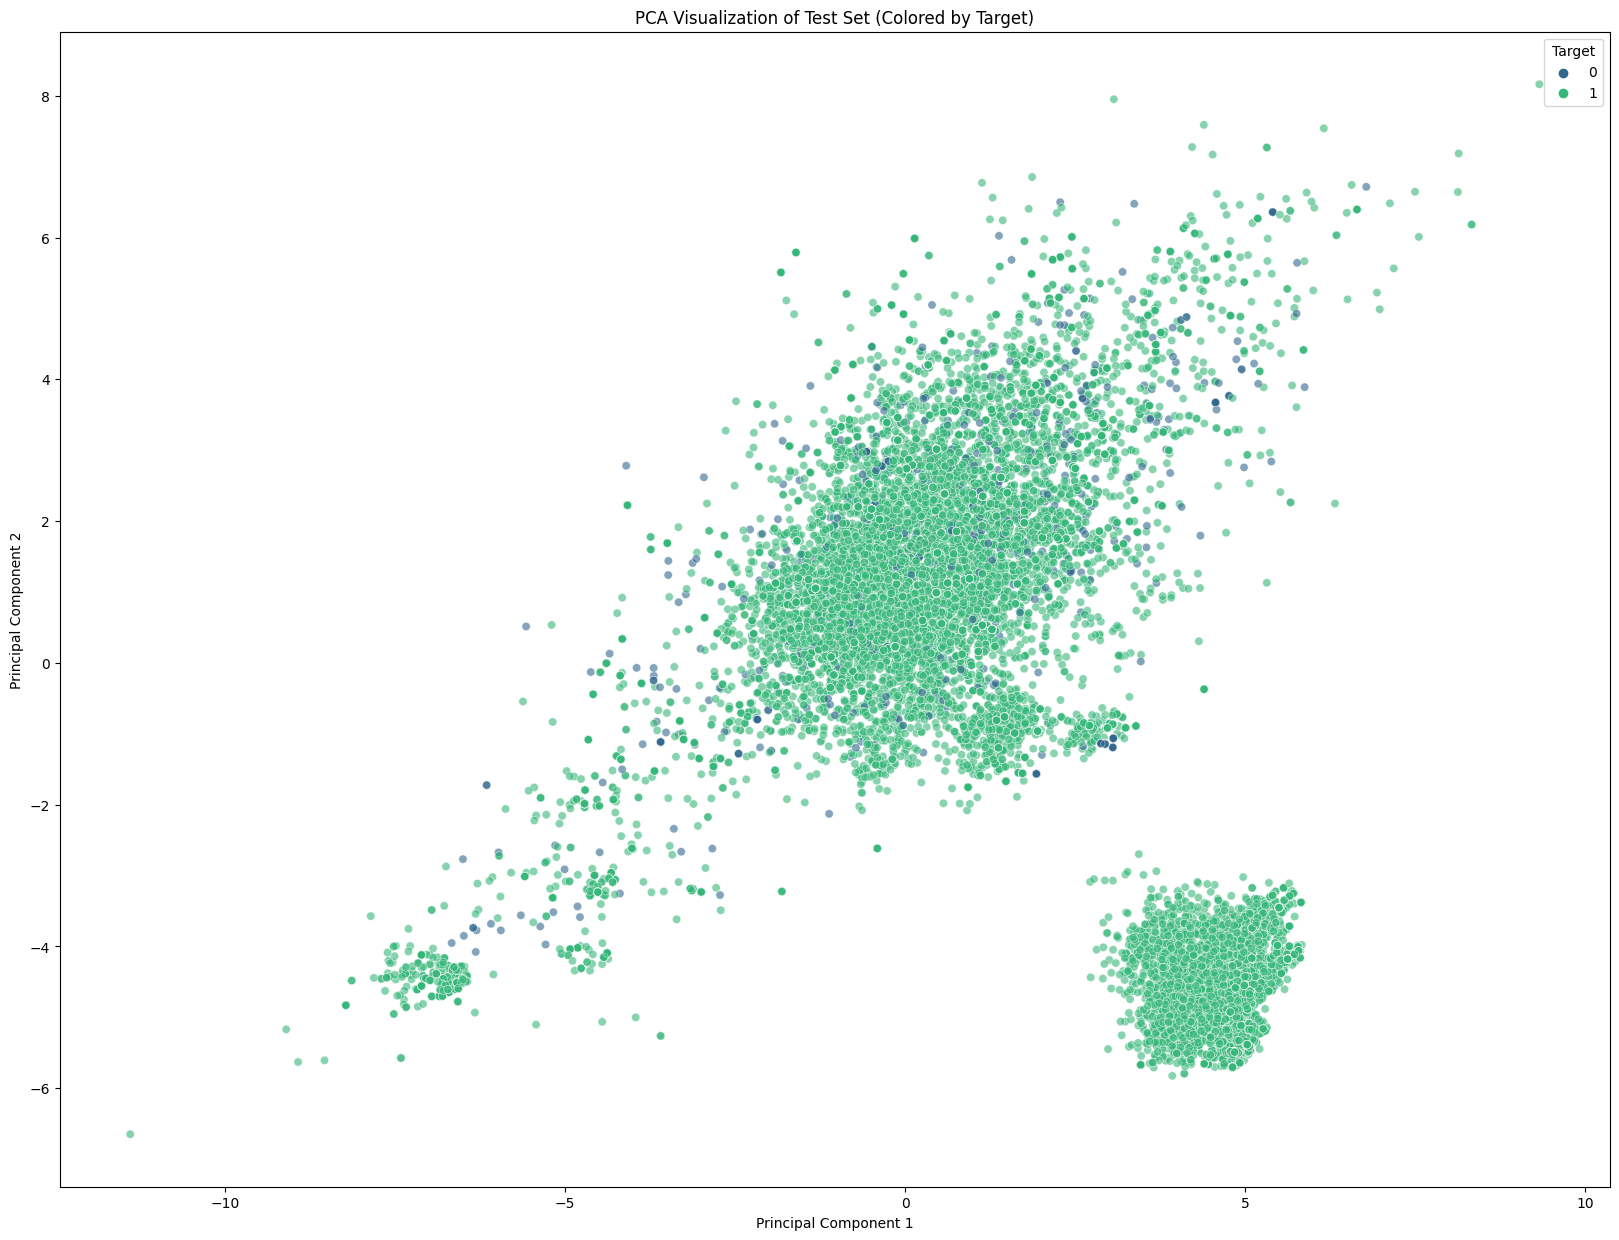

In [ ]:
plot_data = pd.DataFrame({
    'PC1': x_train[:, 0],
    'PC2': x_train[:, 1],
    'Target': y_train
})

plt.figure(figsize=(20, 15))
sns.scatterplot(
    data=plot_data,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="viridis",
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Test Set (Colored by Target)")

plt.show()

**Interpretation of Visualization (Pre-Oversampling)**

The scatter plot of the data after PCA transformation (colored by the original malware target) visually confirms the initial class imbalance and reveals the complexity of the classification task:

- Cluster Structure: The majority of data points, corresponding to the malware class (1), form a large, densely packed cluster in the 2D plane.
- Minority Class Distribution: The minority class (benign, 0) is scattered across the periphery of the malware cluster, indicating significant overlap between the two classes in the projected 2D space.
- Linear Separability: The intertwined nature of the two classes confirms that the data is not linearly separable in this 2D space. A single straight line (which the Perceptron is limited to finding) would be unable to perfectly divide the two colors, suggesting that the model will struggle to achieve high performance on the test set.

**Oversampling (SMOTE)**

The severe class imbalance observed earlier (approximately 97.6% malware) necessitates the use of a technique to balance the training data.
- SMOTE: Synthetic Minority Over-sampling Technique (SMOTE) addresses imbalance by generating synthetic examples for the minority class. SMOTE works by selecting a minority sample and finding its $k$ nearest neighbors. New synthetic samples are then created at random points along the line segments connecting the selected sample to its neighbors.
- Application: SMOTE is applied only to the PCA-transformed training data (`X_train` and `y_train`). This step is strictly performed post-split and post-PCA to prevent data leakage and avoid potential noise injection into the core transformation. The resulting training set is successfully balanced, achieving a $50$ percent / $50$ percent distribution between the two classes, making the subsequent Perceptron training more equitable.

In [ ]:
smote = SMOTE(random_state=42)
print("Shape of original x_train:", x_train.shape)
print("Shape of original y_train:", y_train.shape)
x_train, y_train = smote.fit_resample(x_train, y_train)

print("Shape of original x_train:", x_train.shape)
print("Shape of original y_train:", y_train.shape)
y_train.value_counts(normalize=True)*100

Shape of original x_train: (35100, 2)
Shape of original y_train: (35100,)
Shape of original x_train: (68494, 2)
Shape of original y_train: (68494,)


malware
1    50.0
0    50.0
Name: proportion, dtype: float64

**After Oversampling Visualization**

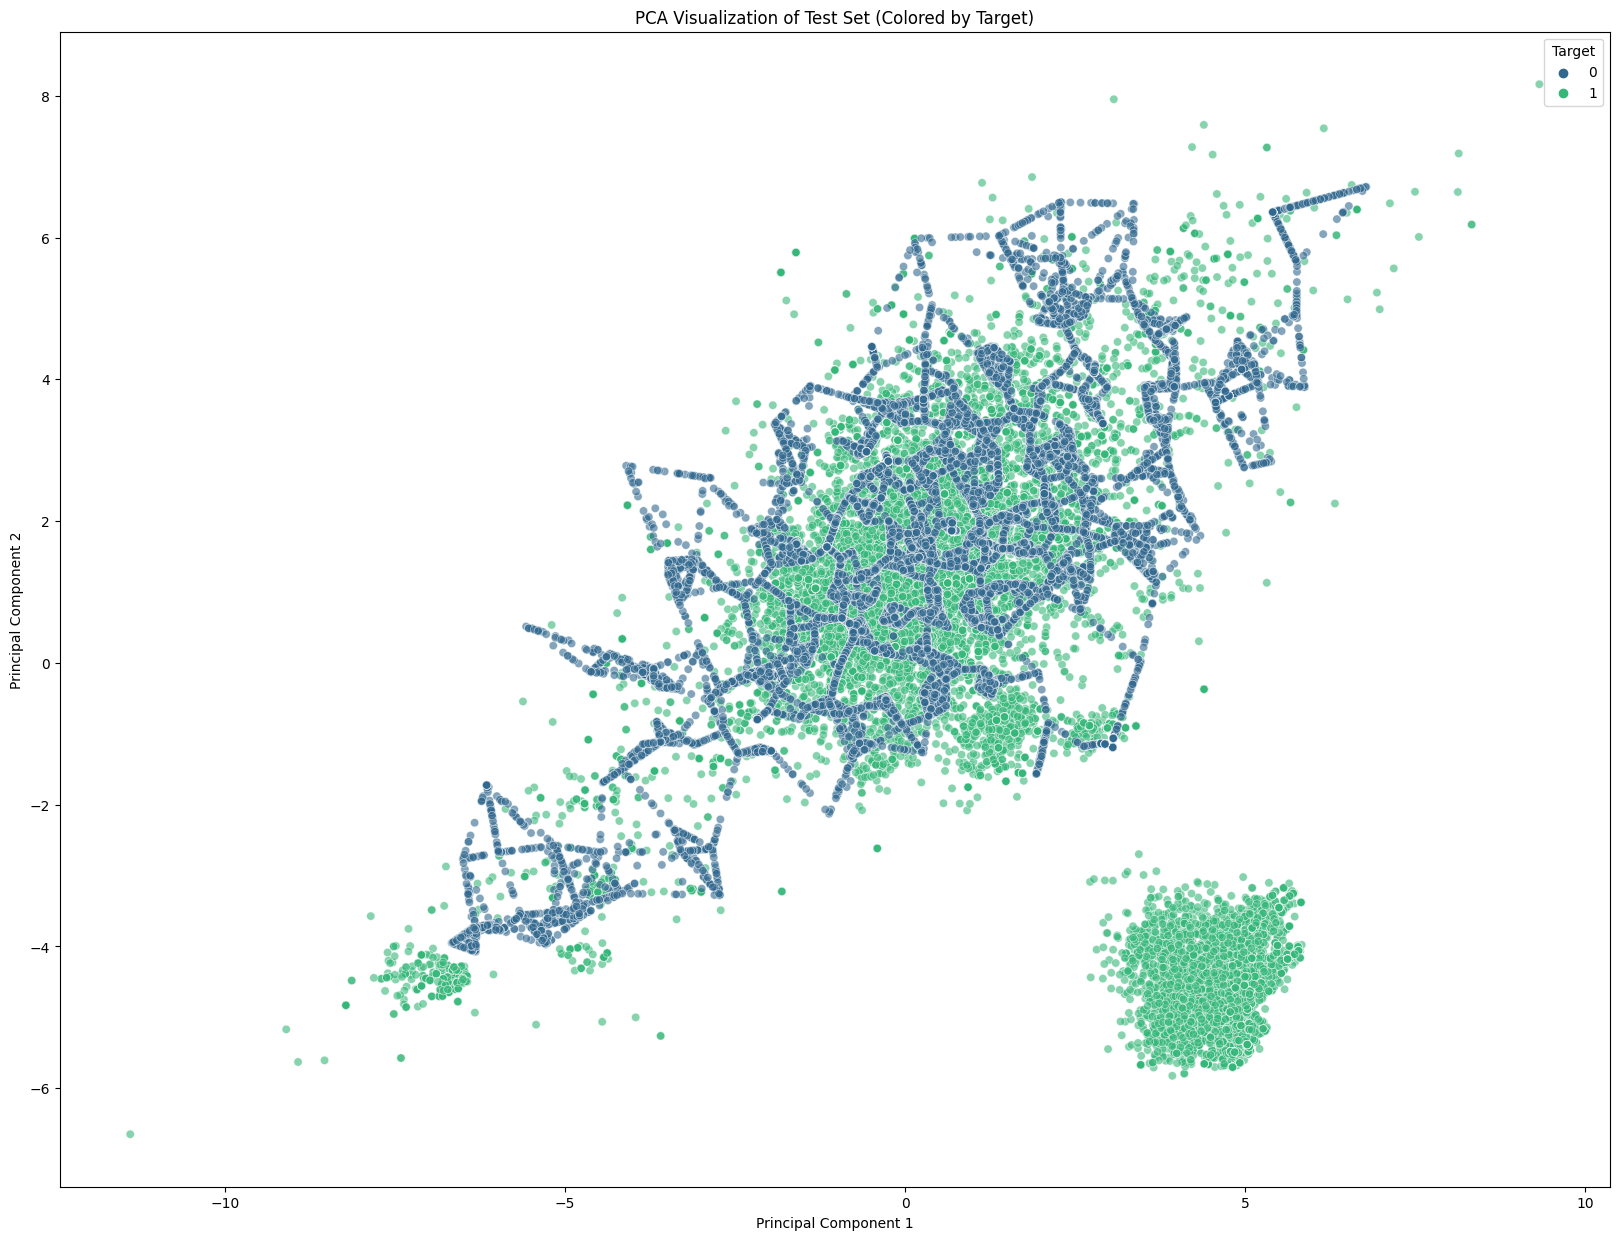

In [ ]:
plot_data = pd.DataFrame({
    'PC1': x_train[:, 0],
    'PC2': x_train[:, 1],
    'Target': y_train
})

plt.figure(figsize=(20, 15))
sns.scatterplot(
    data=plot_data,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="viridis",
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Test Set (Colored by Target)")

plt.show()

**Interpretation of Visualization (Post-Oversampling)**

The scatter plot of the data after SMOTE application clearly shows the effect of the oversampling technique:

- Density Increase: The region occupied by the minority class (benign, 0) is now significantly more dense.
- Synthesized Points: New data points have been interpolated along the boundaries and within the existing minority clusters. This effectively equalizes the size of the two classes and modifies the decision boundary area in the training space.
- Training Advantage: The balanced distribution allows the Perceptron to focus its learning on the features of the minority class, which was previously overwhelmed by the majority class. Although the overlap remains, the model now has sufficient minority examples to learn a separating hyperplane, even if it is imperfect.

# Model Training and Experiments

## Model Architecture and Model Training

**The Perceptron Model in Scikit-Learn**

The sklearn.linear_model.Perceptron class implements the classic, single-layer Perceptron algorithm, functioning as an online linear classifier for supervised classification tasks. It seeks to find a single hyperplane that linearly separates data into two classes. The model is an online learner, meaning it updates its internal weights incrementally after processing each individual training sample, which makes it particularly suitable for large datasets that cannot be loaded entirely into memory.

While the original Perceptron is strictly binary, the Scikit-Learn version extends its capability to handle multiple classes using the One-vs-Rest (OvR) approach. This involves training a distinct binary Perceptron for every class, and the final prediction is assigned to the class whose corresponding classifier yields the highest score.

**Model Selection and Training Strategy**

The chosen model for this binary classification task is the Perceptron, a linear classifier and the progenitor of neural networks. The Scikit-Learn implementation of the Perceptron is used, which learns a separating hyperplane using the Perceptron training rule.

Cross-Validation (CV): The model is initially assessed using 5-fold stratified cross-validation on the SMOTE-balanced training data. Stratified CV is essential when dealing with imbalanced datasets (even after balancing with SMOTE), as it ensures that each fold maintains the same proportion of classes as the overall training set. This methodology provides a more robust estimate of the model's performance by training and evaluating the model five separate times on different data subsets. The primary metric for this initial assessment is accuracy.

In [ ]:
ml_models = [
    ("Perceptron", Perceptron(random_state=42, tol=1e-3, eta0=1.0)) # Added tol and eta0 for convergence
]

for model_name, model in ml_models:
    print(f"{model_name}: ")
    model.fit(x_train, y_train) 
    cv_scores = cross_val_score(model, x_train, y_train, cv=5, scoring='accuracy')  # Cross-validation
    print("\tStratified K-Fold Cross-Validation Scores:", cv_scores)
    print('-' * 100)
    print(f'\tAverage Stratified K-Fold Cross-Validation Score: {cv_scores.mean():.4f}')
    print('-' * 100)

Perceptron: 
	Stratified K-Fold Cross-Validation Scores: [0.56047887 0.54792321 0.51011023 0.56748668 0.54088188]
----------------------------------------------------------------------------------------------------
	Average Stratified K-Fold Cross-Validation Score: 0.5454
----------------------------------------------------------------------------------------------------


**Perceptron Architecture**

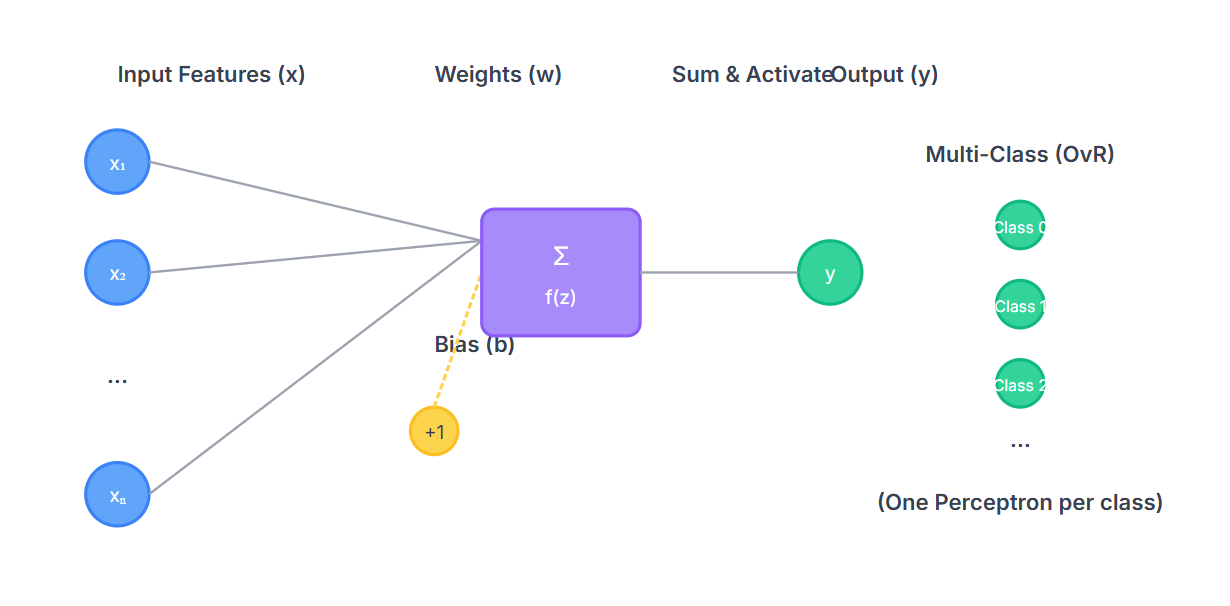

The Perceptron is a fundamental building block of neural networks, representing a simple linear classifier. In scikit-learn, the `Perceptron` model typically handles multi-class classification using a "one-vs-rest" (OvR) strategy, meaning it trains a separate binary perceptron for each class.

**Hyperparameter Tuning**

**Key Hyperparameters and Their Roles**

Several hyperparameters are provided to control the learning process, convergence, and regularization of the model:

- `eta0` (Initial Learning Rate): This parameter controls the magnitude of the weight adjustments during the learning process. It defines the step size the algorithm takes when nudging the weights after a misclassified sample. A high $\eta_0$ can lead to unstable training and overshooting the optimal solution, while a low $\eta_0$ results in slower, more meticulous convergence.
- `max_iter`: Specifies the maximum number of training epochs, or full passes over the entire training dataset. This is a critical parameter because the Perceptron is not guaranteed to converge on data that is not linearly separable. Setting a limit prevents infinite training.
- `tol` (Tolerance): This dictates the stopping criterion for the optimization. Training will stop early if the model's improvement in loss between consecutive epochs is less than this threshold, saving computation time once the model stabilizes.
- `penalty and alpha`: These parameters manage regularization, a technique used to combat overfitting. The penalty parameter determines the type of regularization term added to the loss function (e.g., $L_2$ or Elastic Net). The alpha parameter controls the strength of this regularization. A higher $\alpha$ increases the penalty for large weights, encouraging simpler models that generalize better by being less sensitive to noise in the training data.
- `fit_intercept`: This is a boolean parameter determining whether the decision function includes a bias term. When True, the model learns an offset, allowing the separating hyperplane to be positioned anywhere in the feature space, rather than forcing it through the origin.
- `shuffle`: A boolean that controls whether the training data should be randomly reordered after each epoch. Shuffling the order of samples helps prevent the online learning process from getting stuck in cyclical patterns and is generally recommended for better convergence.

**Hyperparameter Tuning with GridSearchCV**

To maximize the Perceptron's performance, hyperparameter tuning is conducted using GridSearchCV. This technique systematically searches through a predefined grid of hyperparameter values, training and evaluating the model for every possible combination using cross-validation.

Key Hyperparameters Tuned:

- `alpha` (Alpha): Represents the strength of the $L_2$ regularization term. Regularization prevents overfitting by penalizing large weights, helping the model generalize better to unseen data.
- `eta_0` (Eta0): The initial learning rate, which controls the step size of the weight updates.
- `max_iter`: The maximum number of epochs (passes over the entire training set) allowed, defining the training duration.
- `tol` (Tolerance): The stopping criterion; the training halts if the improvement in the cost function is less than this tolerance.
- `fit_intercept`: A boolean indicating whether the decision boundary should include a bias term.

The search selects the optimal set of parameters that yield the highest cross-validated accuracy, resulting in the best estimator used for final analysis.

In [ ]:
param_grid = {
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
    'fit_intercept': [True, False],
    'max_iter': [500, 1000, 1500],
    'eta0': [0.1, 0.5, 1.0],
    'tol': [1e-4, 1e-3, 1e-2]
}

perceptron = Perceptron(random_state=42)

grid_search = GridSearchCV(
    estimator=perceptron,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Starting GridSearchCV for Perceptron...")
grid_search.fit(x_train, y_train)

print("\n--- GridSearchCV Results ---")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")
print("Best hyperparameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

best_perceptron_model = grid_search.best_estimator_

Starting GridSearchCV for Perceptron...
Fitting 5 folds for each of 270 candidates, totalling 1350 fits

--- GridSearchCV Results ---
Best cross-validation accuracy: 0.5676
Best hyperparameters found:
  alpha: 1e-05
  eta0: 0.1
  fit_intercept: True
  max_iter: 500
  tol: 0.01


**Decision Boundary Visualization**

The final step in this section involves visualizing the optimal Perceptron model's learned behavior by plotting its decision boundary in the 2D PCA-transformed space.

Methodology:

- The space defined by PC1 and PC2 from the training data is mapped onto a dense grid (meshgrid).
- The best-performing Perceptron model predicts the class (0 or 1) for every point on this grid.
- The results are plotted as a filled contour, separating the feature space into two distinct regions predicted by the model.
- The actual training data points are overlaid on this contour, colored by their true class labels.

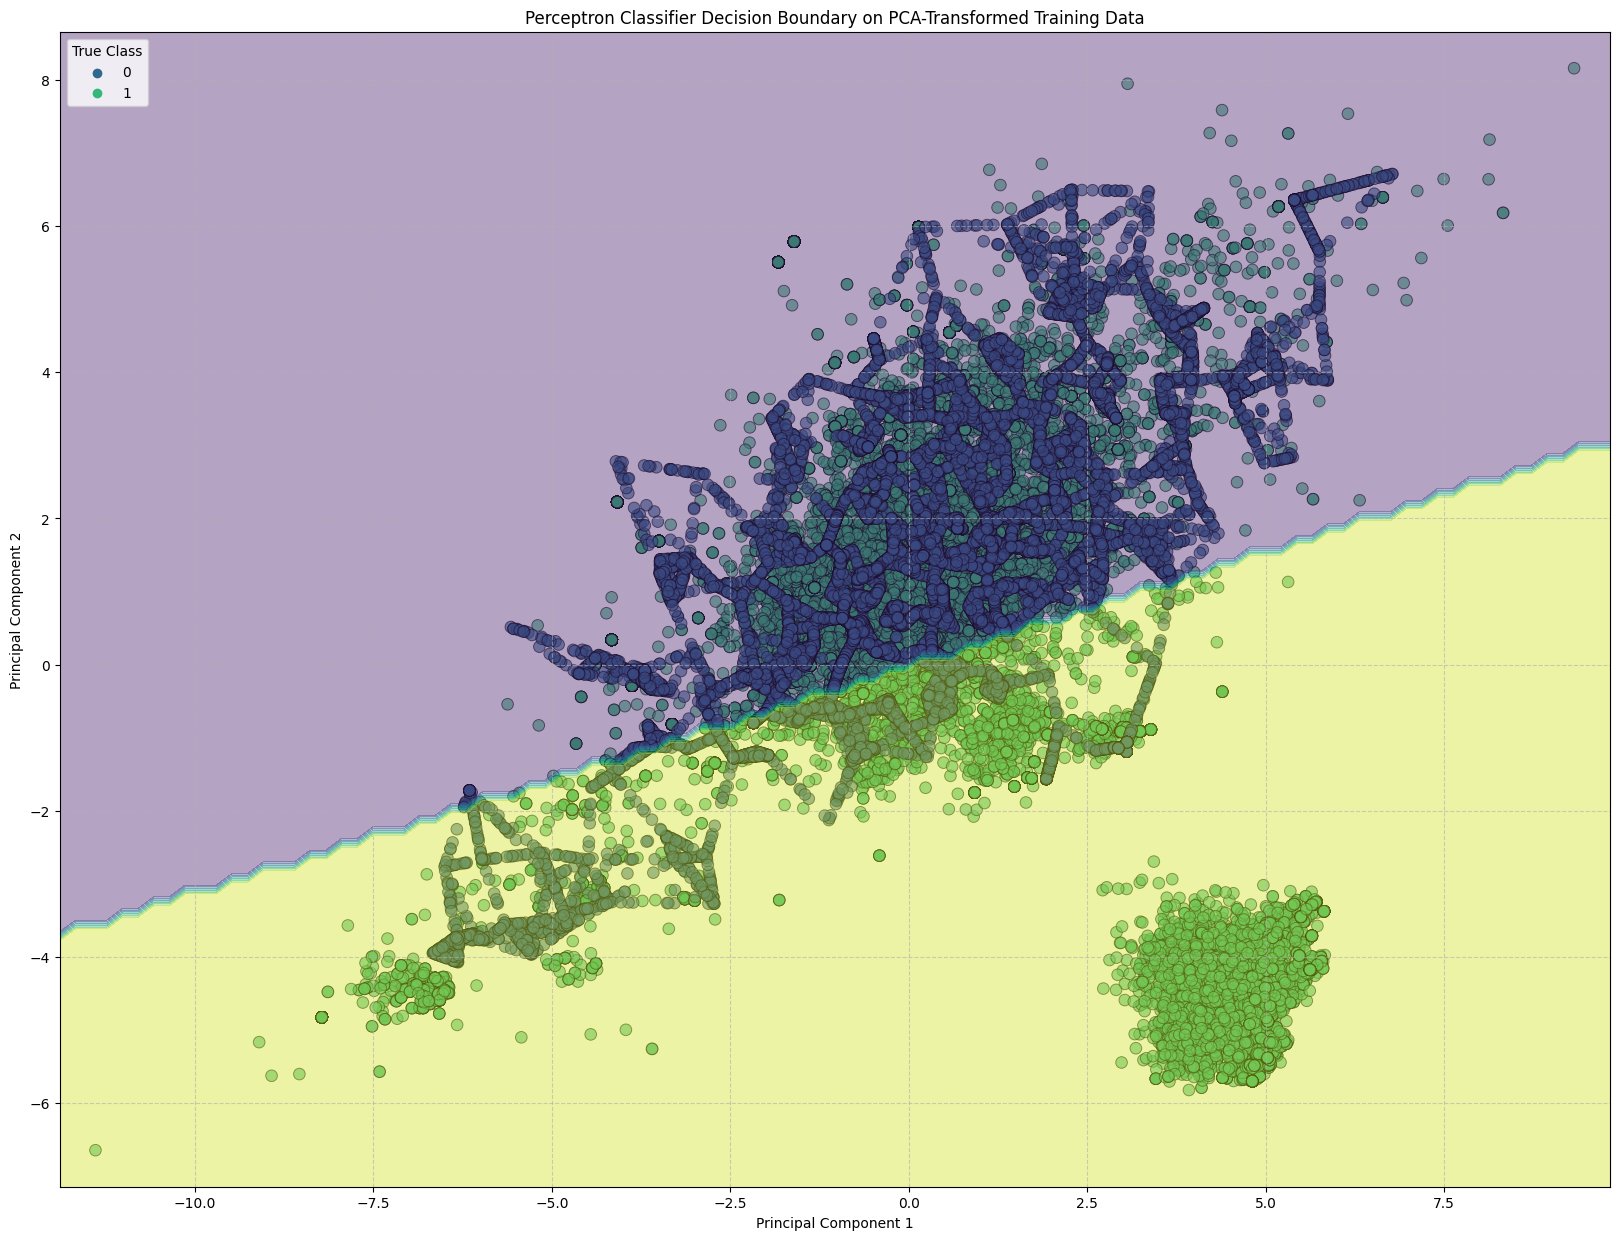

In [ ]:
plot_data_train = pd.DataFrame({
    'PC1': x_train[:, 0],
    'PC2': x_train[:, 1],
    'Target': y_train
})

plt.figure(figsize=(20, 15))
sns.scatterplot(
    data=plot_data_train,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="viridis",
    alpha=0.6,
    edgecolor='k',
    s=70
)

x_min, x_max = x_train[:, 0].min() - 0.5, x_train[:, 0].max() + 0.5
y_min, y_max = x_train[:, 1].min() - 0.5, x_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

Z = best_perceptron_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.viridis)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Perceptron Classifier Decision Boundary on PCA-Transformed Training Data")
plt.legend(title="True Class")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Interpretation of Visualization Results (Training Data)**

The visualization of the decision boundary provides clear insights into the capabilities and limitations of the Perceptron model on the preprocessed data:

- Linear Separation: The boundary appears as a single, straight line dividing the 2D feature space. This visually confirms the fundamental nature of the Perceptron as a linear classifier, constrained to defining a single hyperplane.
- Overlap and Misclassification: The visualization clearly shows that the two classes (malware and benign) exhibit significant overlap, even after SMOTE oversampling. Consequently, a single straight line cannot perfectly separate the points.
- Training Error: Numerous data points, particularly those near the boundary or mixed within the cluster of the opposite class, fall into the wrong colored contour region. This visually indicates the presence of training error and explains the moderate accuracy score obtained during cross-validation. The linear model is simply unable to resolve the inherent non-linearity and intertwining of the malware sequence data projected onto these two principal components.
- SMOTE Effect: The plot reveals the synthesized benign samples (Class 0) have extended the reach of that class's cluster, allowing the Perceptron to place the boundary in a position that better defends the minority class compared to what would have been possible on the original, highly imbalanced data.

# Model Evaluation

**Performance Metrics on Unseen Data**

Model generalization is quantified by evaluating the Accuracy of the best-performing, tuned Perceptron model on the dedicated test dataset. Accuracy represents the proportion of correct predictions (both true positives and true negatives) across all instances.

In [23]:
test_accuracy = best_perceptron_model.score(x_test, y_test)
print("Accuracy on test set (with best model): {:.4f}".format(test_accuracy))

Accuracy on test set (with best model): 0.4022


The overall accuracy on the test set is low (0.402). This low value is heavily influenced by the model's bias toward the majority class (Class 1, likely benign). The raw classification support shows a high majority for Class 1 (8550 samples) and a tiny minority for Class 0 (226 samples).

**Classification Reports**

In [ ]:
y_pred = best_perceptron_model.predict(x_test)

cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro', zero_division=1)
recall = recall_score(y_test, y_pred, average='macro', zero_division=1)
f1 = f1_score(y_test, y_pred, average='macro', zero_division=1)

y_pred_decision_scores = best_perceptron_model.decision_function(x_test)

roc_auc = roc_auc_score(y_test, y_pred_decision_scores)

print("\n--- Performance Metrics (User-Specified Best Perceptron) ---")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"AUC-ROC: {roc_auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=1))


--- Performance Metrics (User-Specified Best Perceptron) ---
Accuracy: 0.402
Precision: 0.500
Recall: 0.504
F1-score: 0.307
AUC-ROC: 0.536

Classification Report:
              precision    recall  f1-score   support

           0       0.03      0.61      0.05       226
           1       0.97      0.40      0.56      8550

    accuracy                           0.40      8776
   macro avg       0.50      0.50      0.31      8776
weighted avg       0.95      0.40      0.55      8776



However, given the inherent class skew in the original problem (evident by the large disparity in class support on the test set: 226 for Class 0 and 8550 for Class 1), relying solely on accuracy is misleading. Therefore, the evaluation incorporates metrics designed to assess performance on unbalanced data:
- Precision: The ability of the classifier not to label as positive an instance that is actually negative. High precision means a low false positive rate.
- Recall (Sensitivity): The ability of the classifier to find all the positive instances. High recall means a low false negative rate.
- F1-Score: The harmonic mean of precision and recall, offering a single metric that balances both.
- AUC-ROC (Area Under the Receiver Operating Characteristic Curve): A measure of the model's ability to distinguish between classes across all classification thresholds. A value near 0.5 indicates performance equivalent to random guessing.

**Confusion Metrics**

The Confusion Matrix provides a detailed breakdown of correct and incorrect predictions, illustrating which classes are being confused. The matrix visualizes the relationship between True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN).

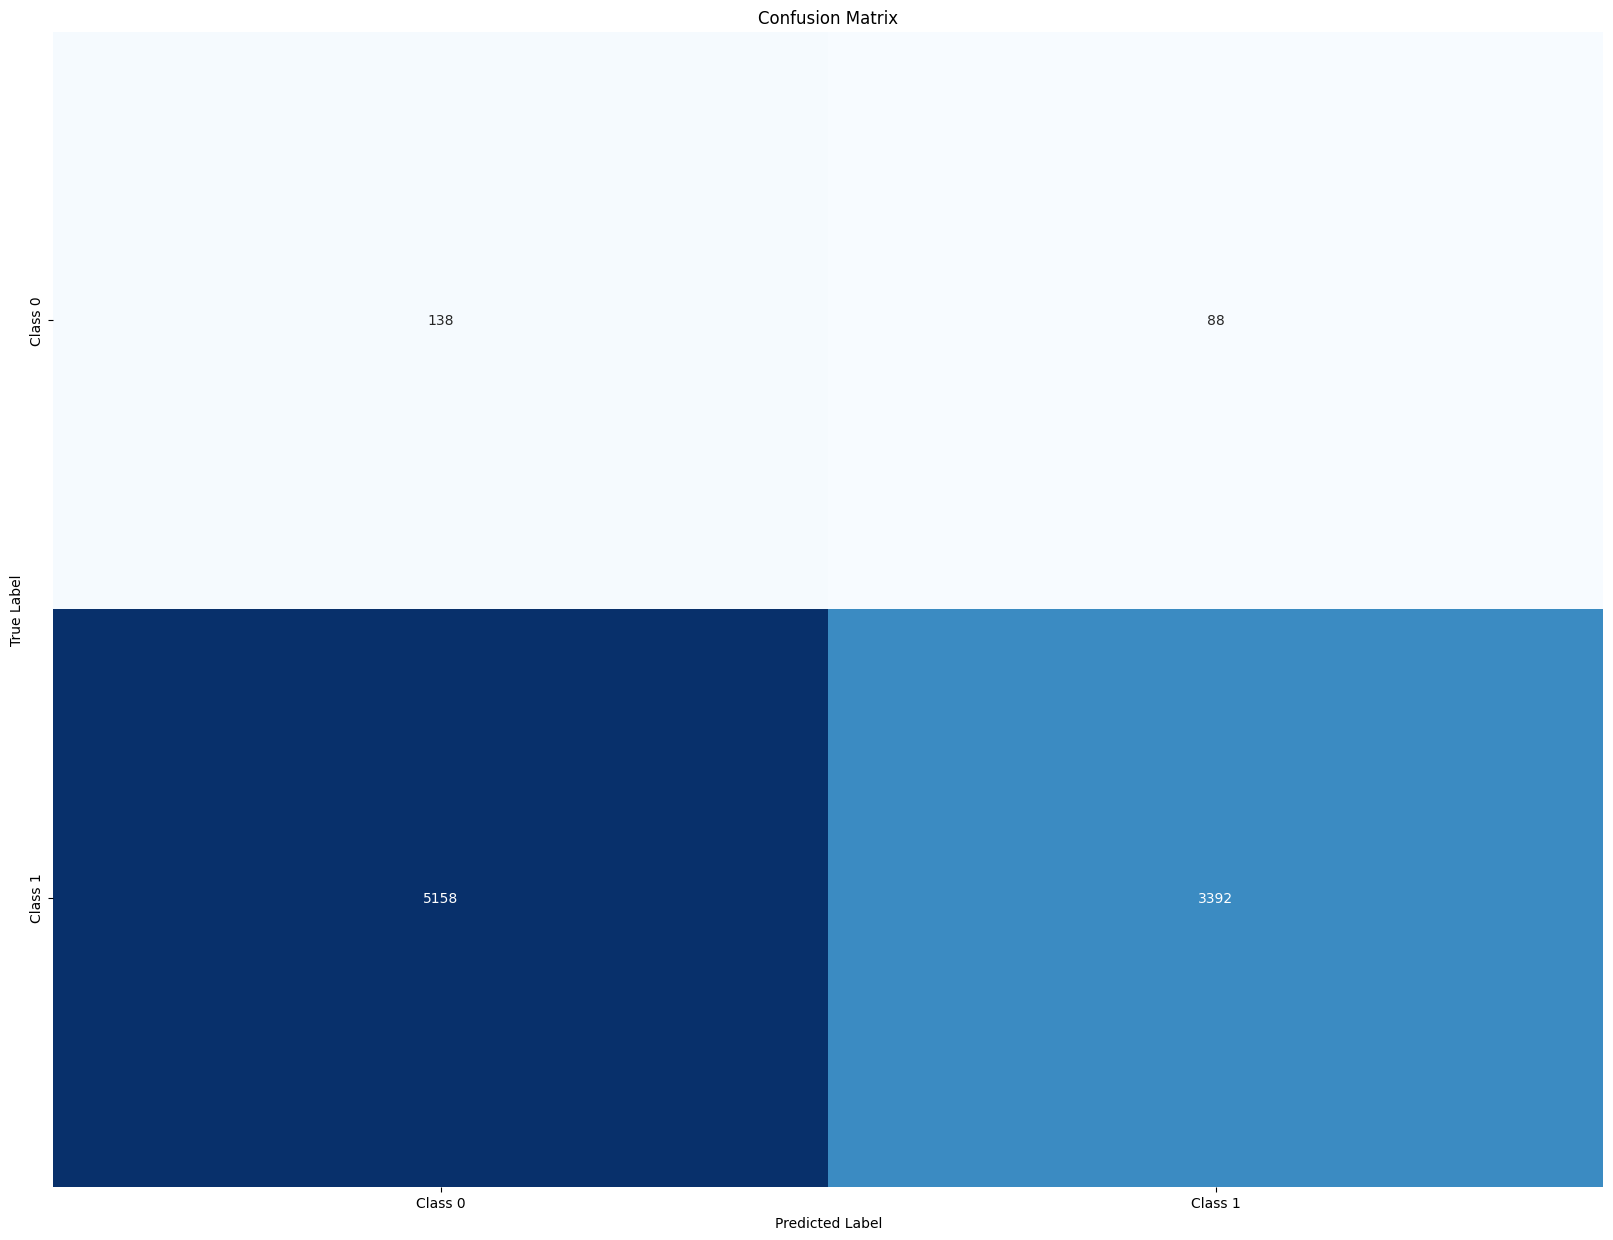

In [ ]:
plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

**Interpretation of Visualization Results**

The collected performance metrics and visualizations paint a consistent picture of the Perceptron's limitations on this dataset:

- Classification Report Disparity: The report highlights severe performance degradation for Class 0 (the minority class, potentially malware).
    - Class 0 Recall (0.61): Indicates that 61% of the actual Class 0 samples were correctly identified, suggesting reasonable coverage of the minority class features.
    - Class 0 Precision (0.03): This extremely low value means that only 3% of the samples the model predicted as Class 0 were actually correct. This results in a massive number of False Positives, where many majority class samples were incorrectly flagged as Class 0.
    - Class 1 Metrics: Conversely, Class 1 (majority) has high precision (0.97) but low recall (0.40), confirming the model's tendency to incorrectly label true Class 1 samples as Class 0 (high False Positives for Class 0 translates to high False Negatives for Class 1).
- Confusion Matrix Visualization: The matrix numerically confirms the severe misclassification pattern. The majority of the small number of true Class 0 instances are correctly classified, but the model incorrectly classifies thousands of Class 1 instances as Class 0, leading to the low accuracy and poor Class 0 precision.

**Precision-Recall Curve**


--- Plotting Precision-Recall Curve ---


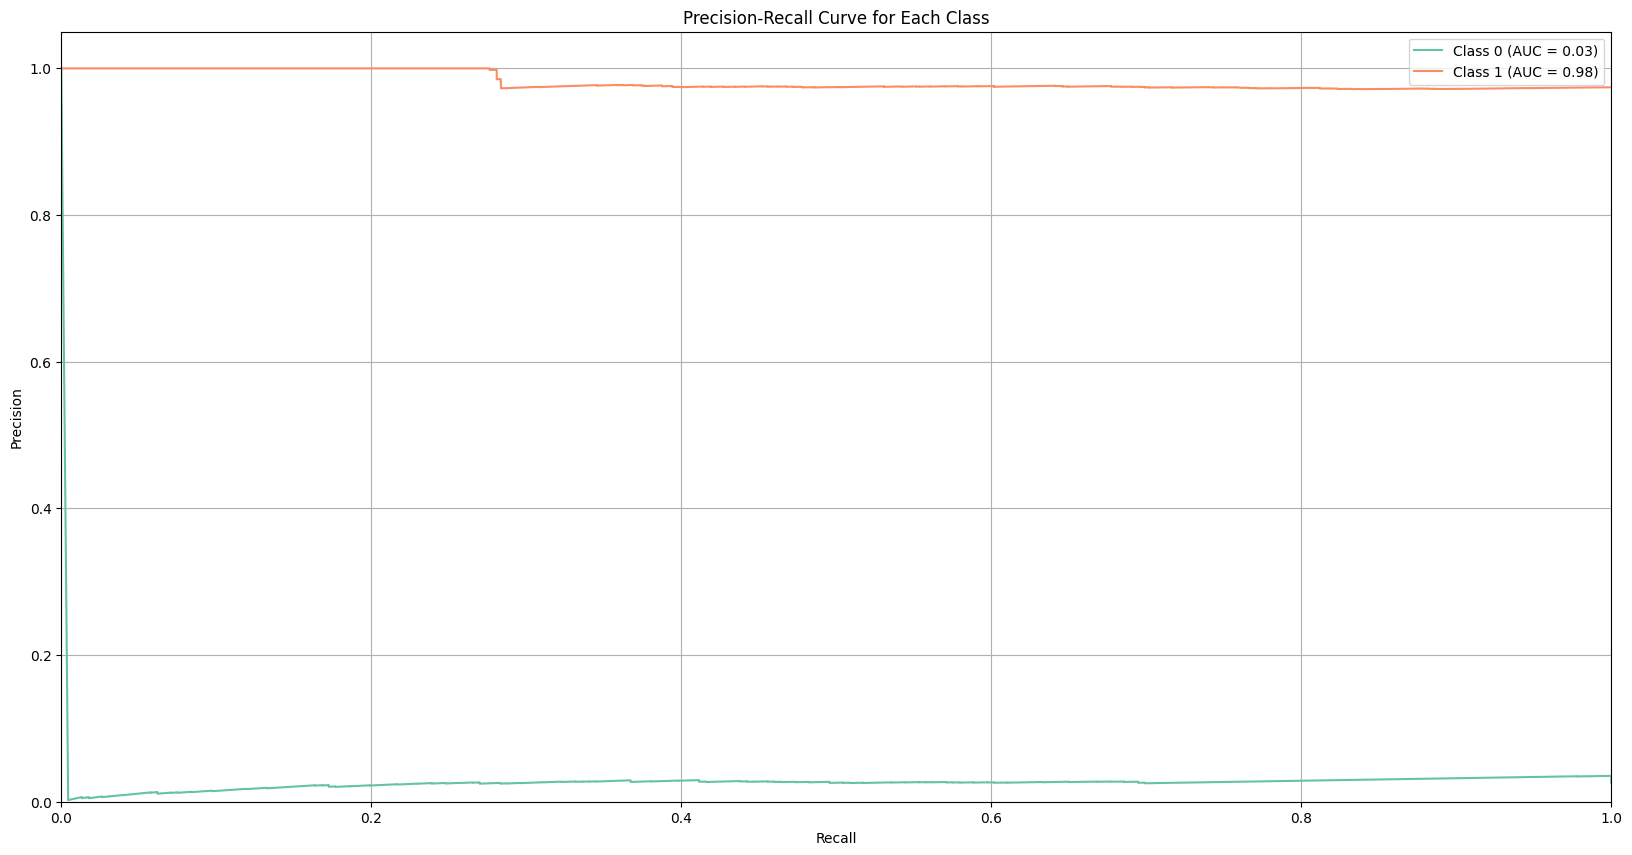

In [ ]:
print("\n--- Plotting Precision-Recall Curve ---")

class_labels = ["0", "1"]

plt.figure(figsize=(20, 10))

sns.set_palette("Set2")

all_class_decision_scores = best_perceptron_model.decision_function(x_test)

for i, label in enumerate(class_labels):
    y_test_bin = np.where(y_test == int(label), 1, 0)

    if int(label) == 1:
        y_pred_score = all_class_decision_scores
    else:
        y_pred_score = -all_class_decision_scores

    precision, recall, _ = precision_recall_curve(y_test_bin, y_pred_score)
    pr_auc = auc(recall, precision)

    plt.plot(recall, precision, label=f'Class {label} (AUC = {pr_auc:.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Each Class")
plt.legend(loc="upper right")
plt.ylim([0, 1.05])
plt.xlim([0, 1])
plt.grid(True)

plt.show()

Precision-Recall Curve: The Precision-Recall (PR) curve is crucial for assessing performance on imbalanced data. The low AUC PR values for both classes (especially considering the severe imbalance) indicate the model struggles to maintain high precision while achieving high recall simultaneously. The shape of the curve reflects the poor trade-off between the two metrics.

**ROC AUC Curve**

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  


--- AUC ROC Values per Class ---
Label 0 AUC: 0.5358
Label 1 AUC: 0.5358
------------------------------


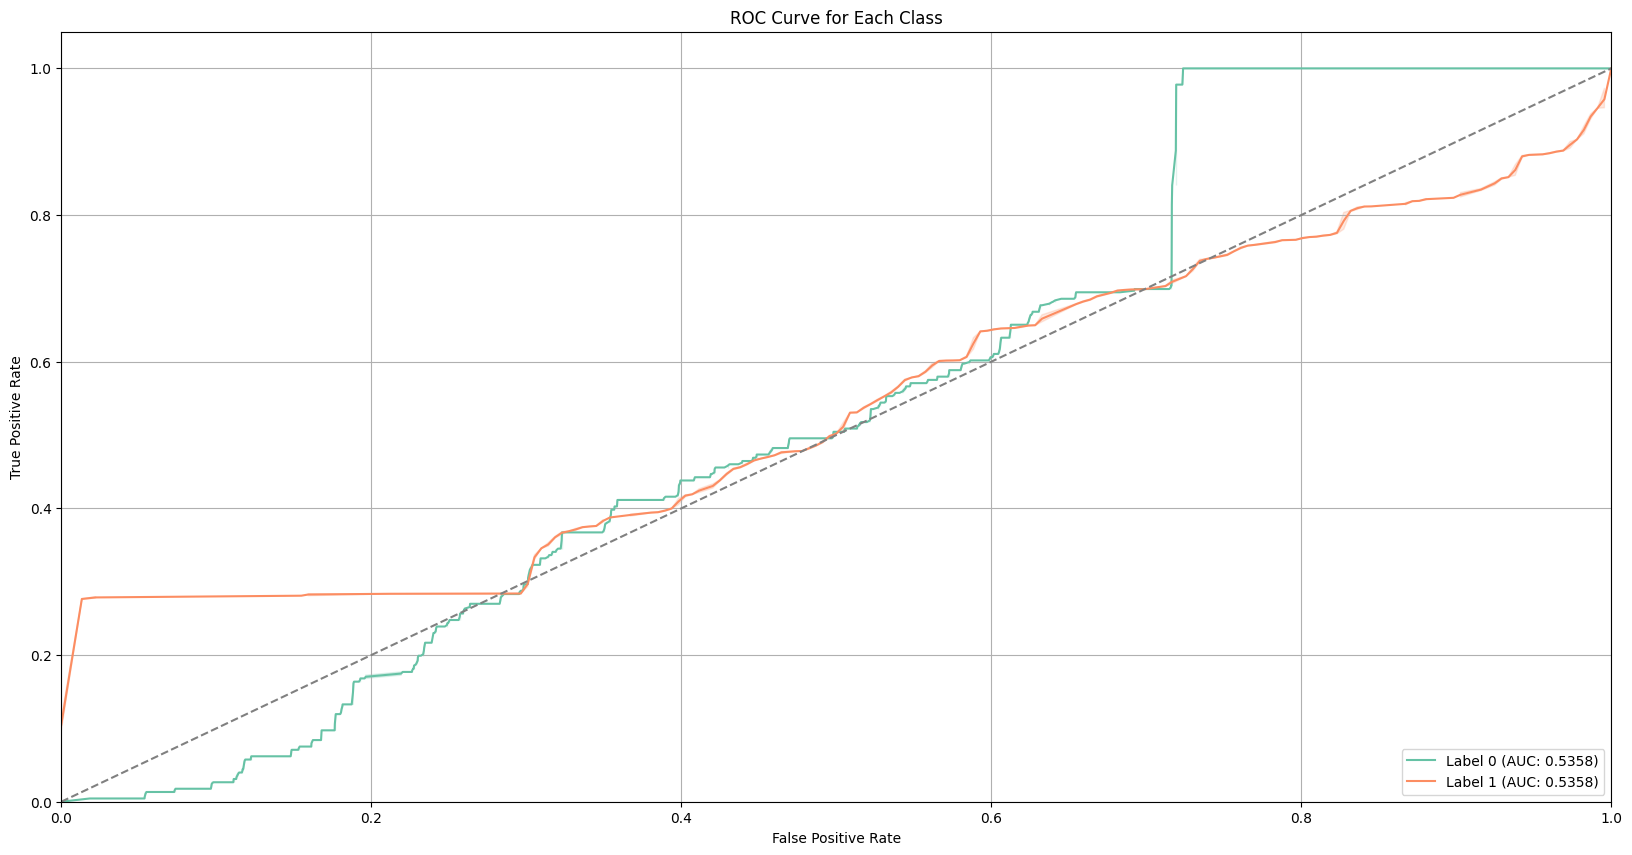

In [ ]:
y_pred_scores = best_perceptron_model.decision_function(x_test)

class_labels = ["Label 0", "Label 1"]
classes = [0, 1]

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(20, 10))

sns.set_palette("Set2")

for i, class_val in enumerate(classes):
    if class_val == 1:
        fpr[class_val], tpr[class_val], _ = roc_curve(y_test, y_pred_scores)
    else:
        fpr[class_val], tpr[class_val], _ = roc_curve(1 - y_test, -y_pred_scores)

    roc_auc[class_val] = auc(fpr[class_val], tpr[class_val])

    sns.lineplot(x=fpr[class_val], y=tpr[class_val], label=f'{class_labels[i]} (AUC: {roc_auc[class_val]:.4f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Class')
plt.legend(loc="lower right")
plt.grid(True)

print("\n--- AUC ROC Values per Class ---")
for class_val in classes:
    print(f"{class_labels[class_val]} AUC: {roc_auc[class_val]:.4f}")
print("-" * 30)

ROC AUC Curve: The AUC-ROC score for both classes is approximately 0.536. An AUC near 0.5 suggests the model's discriminative power is marginally better than random chance. This reinforces the finding that the model is barely learning a meaningful, generalizable separation boundary.

**Decision Boundary Visualization (Test Dataset)**

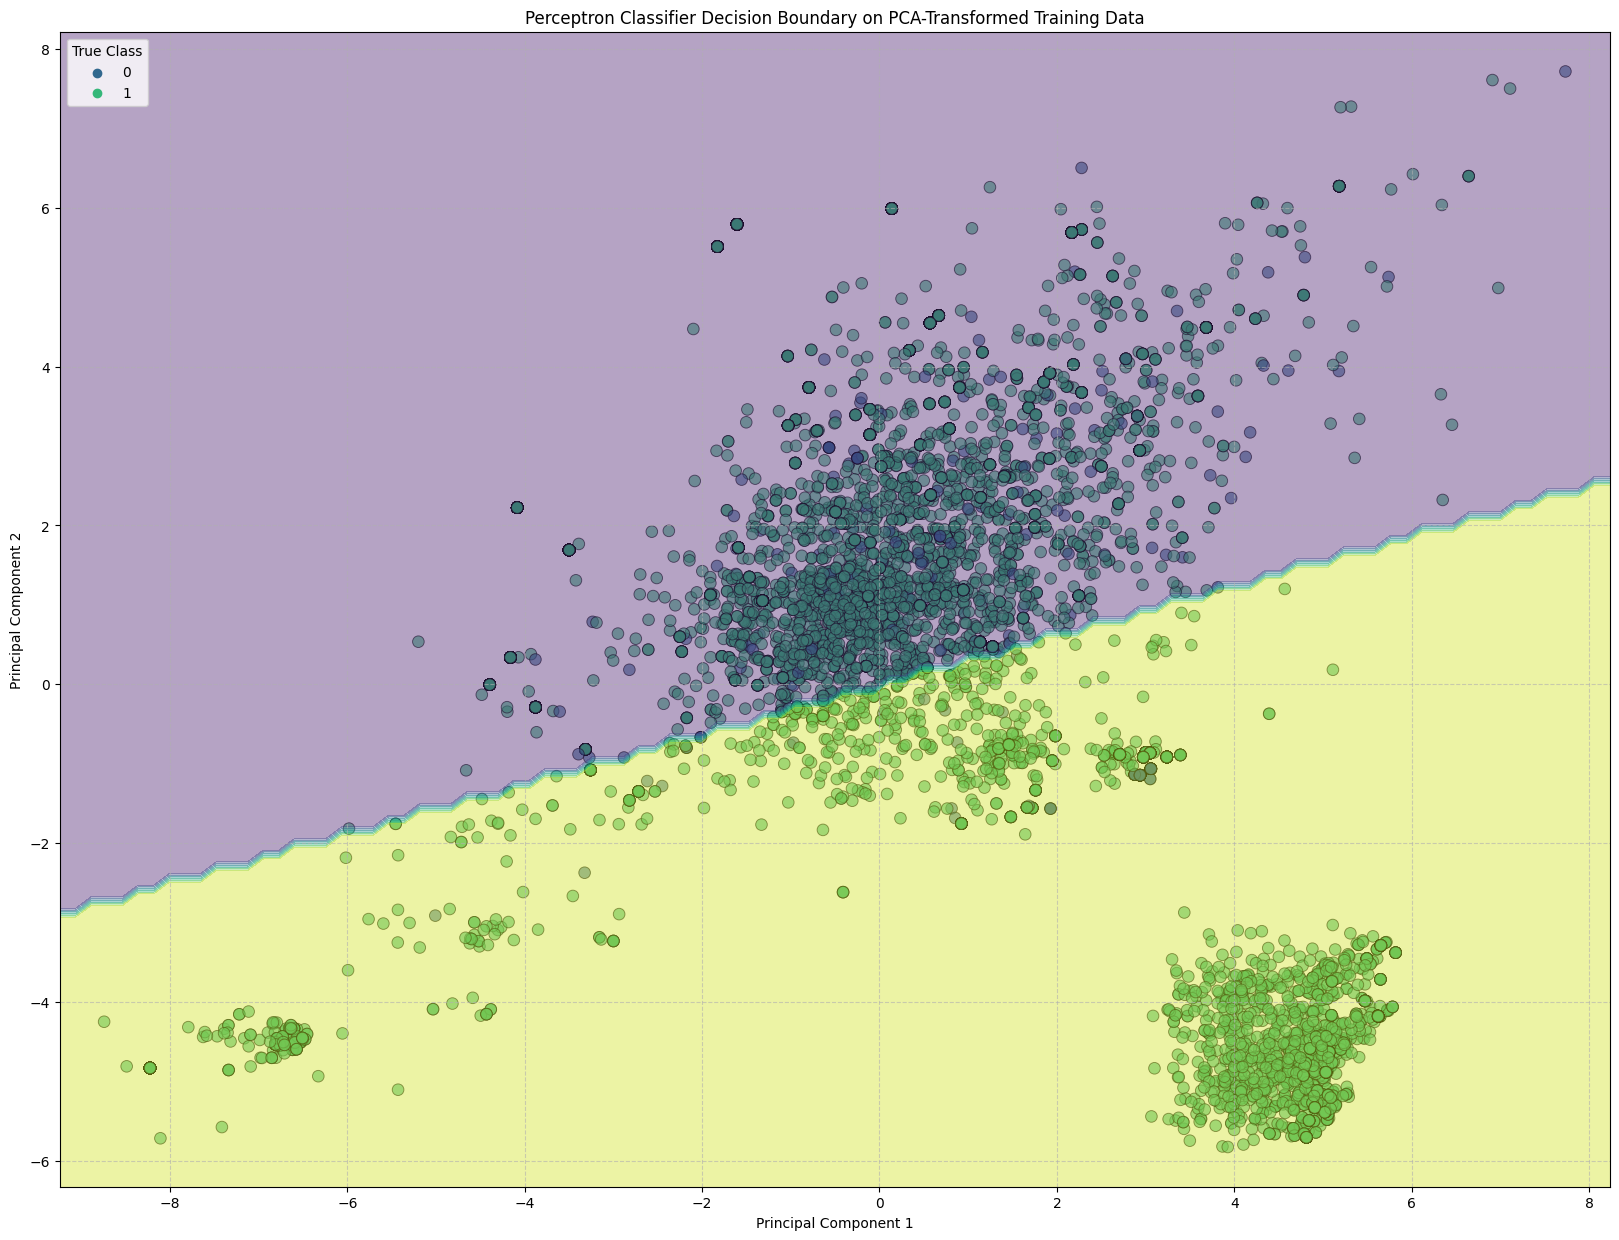

In [ ]:
plot_data_test = pd.DataFrame({
    'PC1': x_test[:, 0],
    'PC2': x_test[:, 1],
    'Target': y_test
})

plt.figure(figsize=(20, 15))
sns.scatterplot(
    data=plot_data_test,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="viridis",
    alpha=0.6,
    edgecolor='k',
    s=70
)

x_min, x_max = x_test[:, 0].min() - 0.5, x_test[:, 0].max() + 0.5
y_min, y_max = x_test[:, 1].min() - 0.5, x_test[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

Z = best_perceptron_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.viridis)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Perceptron Classifier Decision Boundary on PCA-Transformed Training Data")
plt.legend(title="True Class")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Decision Boundary Visualization Interpretation**

Plotting the decision boundary on the test data shows the same single, linear separation line identified during training. The distribution of test points relative to this boundary is highly mixed, confirming that the data remains linearly inseparable. The misclassification of the test points visually explains the low performance metrics, as many points are correctly identified as belonging to Class 1, but the linear boundary captures many Class 1 points and incorrectly assigns them to the Class 0 region.

# Conclusion

This project provides a clear and educational implementation of the classic Perceptron algorithm within a contemporary machine learning pipeline. The core takeaway is the demonstration of the Perceptron's strength—its simplicity and historical significance—alongside its critical weakness: its inherent linearity. Even with robust preprocessing, dimensionality reduction, and class imbalance handling, a single linear decision boundary is often insufficient for complex, non-linearly separable, real-world datasets like malware detection. This project serves as a compelling bridge, underscoring the necessity of moving toward Multi-Layer Perceptrons (MLPs) and non-linear activation functions to handle modern classification challenges effectively.

# References

- [Perceptron Research](https://www.researchgate.net/publication/300873533_Perceptrons)
- [Perceptron Scikit-Learn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html)
- [Perceptron class in Sklearn](https://www.geeksforgeeks.org/machine-learning/sklearn-perceptron/)
- [Neural network models (supervised)](https://scikit-learn.org/stable/modules/neural_networks_supervised.html)
- [Perceptron class in sklearn](https://python-course.eu/machine-learning/perceptron-class-in-sklearn.php)
- [Perceptron Algorithm for Classification using Sklearn](https://www.geeksforgeeks.org/deep-learning/sklearn-classification-using-perceptron/)